In [8]:
quang_guides = !cut -f 2 /PHShome/lf588/scratch/quang_dataset/data/cloud/sample_Jing/18loci_ABE8e_PerturbSeq_guide_set_rev_comp_with_ensembl.tsv 

[chunk 10] pairs=200,000 assigned=66,917 no_hit=133,061 bad_bc=22 bad_umi=0 | 23,690 pairs/s
[chunk 20] pairs=400,000 assigned=133,380 no_hit=266,574 bad_bc=45 bad_umi=1 | 23,720 pairs/s
[chunk 30] pairs=600,000 assigned=200,320 no_hit=399,616 bad_bc=63 bad_umi=1 | 23,717 pairs/s
[chunk 40] pairs=800,000 assigned=266,968 no_hit=532,953 bad_bc=78 bad_umi=1 | 23,744 pairs/s
[chunk 50] pairs=1,000,000 assigned=333,830 no_hit=666,075 bad_bc=89 bad_umi=6 | 23,303 pairs/s
[chunk 60] pairs=1,200,000 assigned=400,649 no_hit=799,231 bad_bc=105 bad_umi=15 | 23,363 pairs/s
[chunk 70] pairs=1,400,000 assigned=467,493 no_hit=932,351 bad_bc=124 bad_umi=32 | 23,406 pairs/s
[chunk 80] pairs=1,600,000 assigned=534,128 no_hit=1,065,672 bad_bc=147 bad_umi=53 | 23,446 pairs/s
[chunk 90] pairs=1,800,000 assigned=601,089 no_hit=1,198,675 bad_bc=173 bad_umi=63 | 23,442 pairs/s
[chunk 100] pairs=2,000,000 assigned=667,740 no_hit=1,331,978 bad_bc=215 bad_umi=67 | 23,462 pairs/s
[chunk 110] pairs=2,200,000 assi

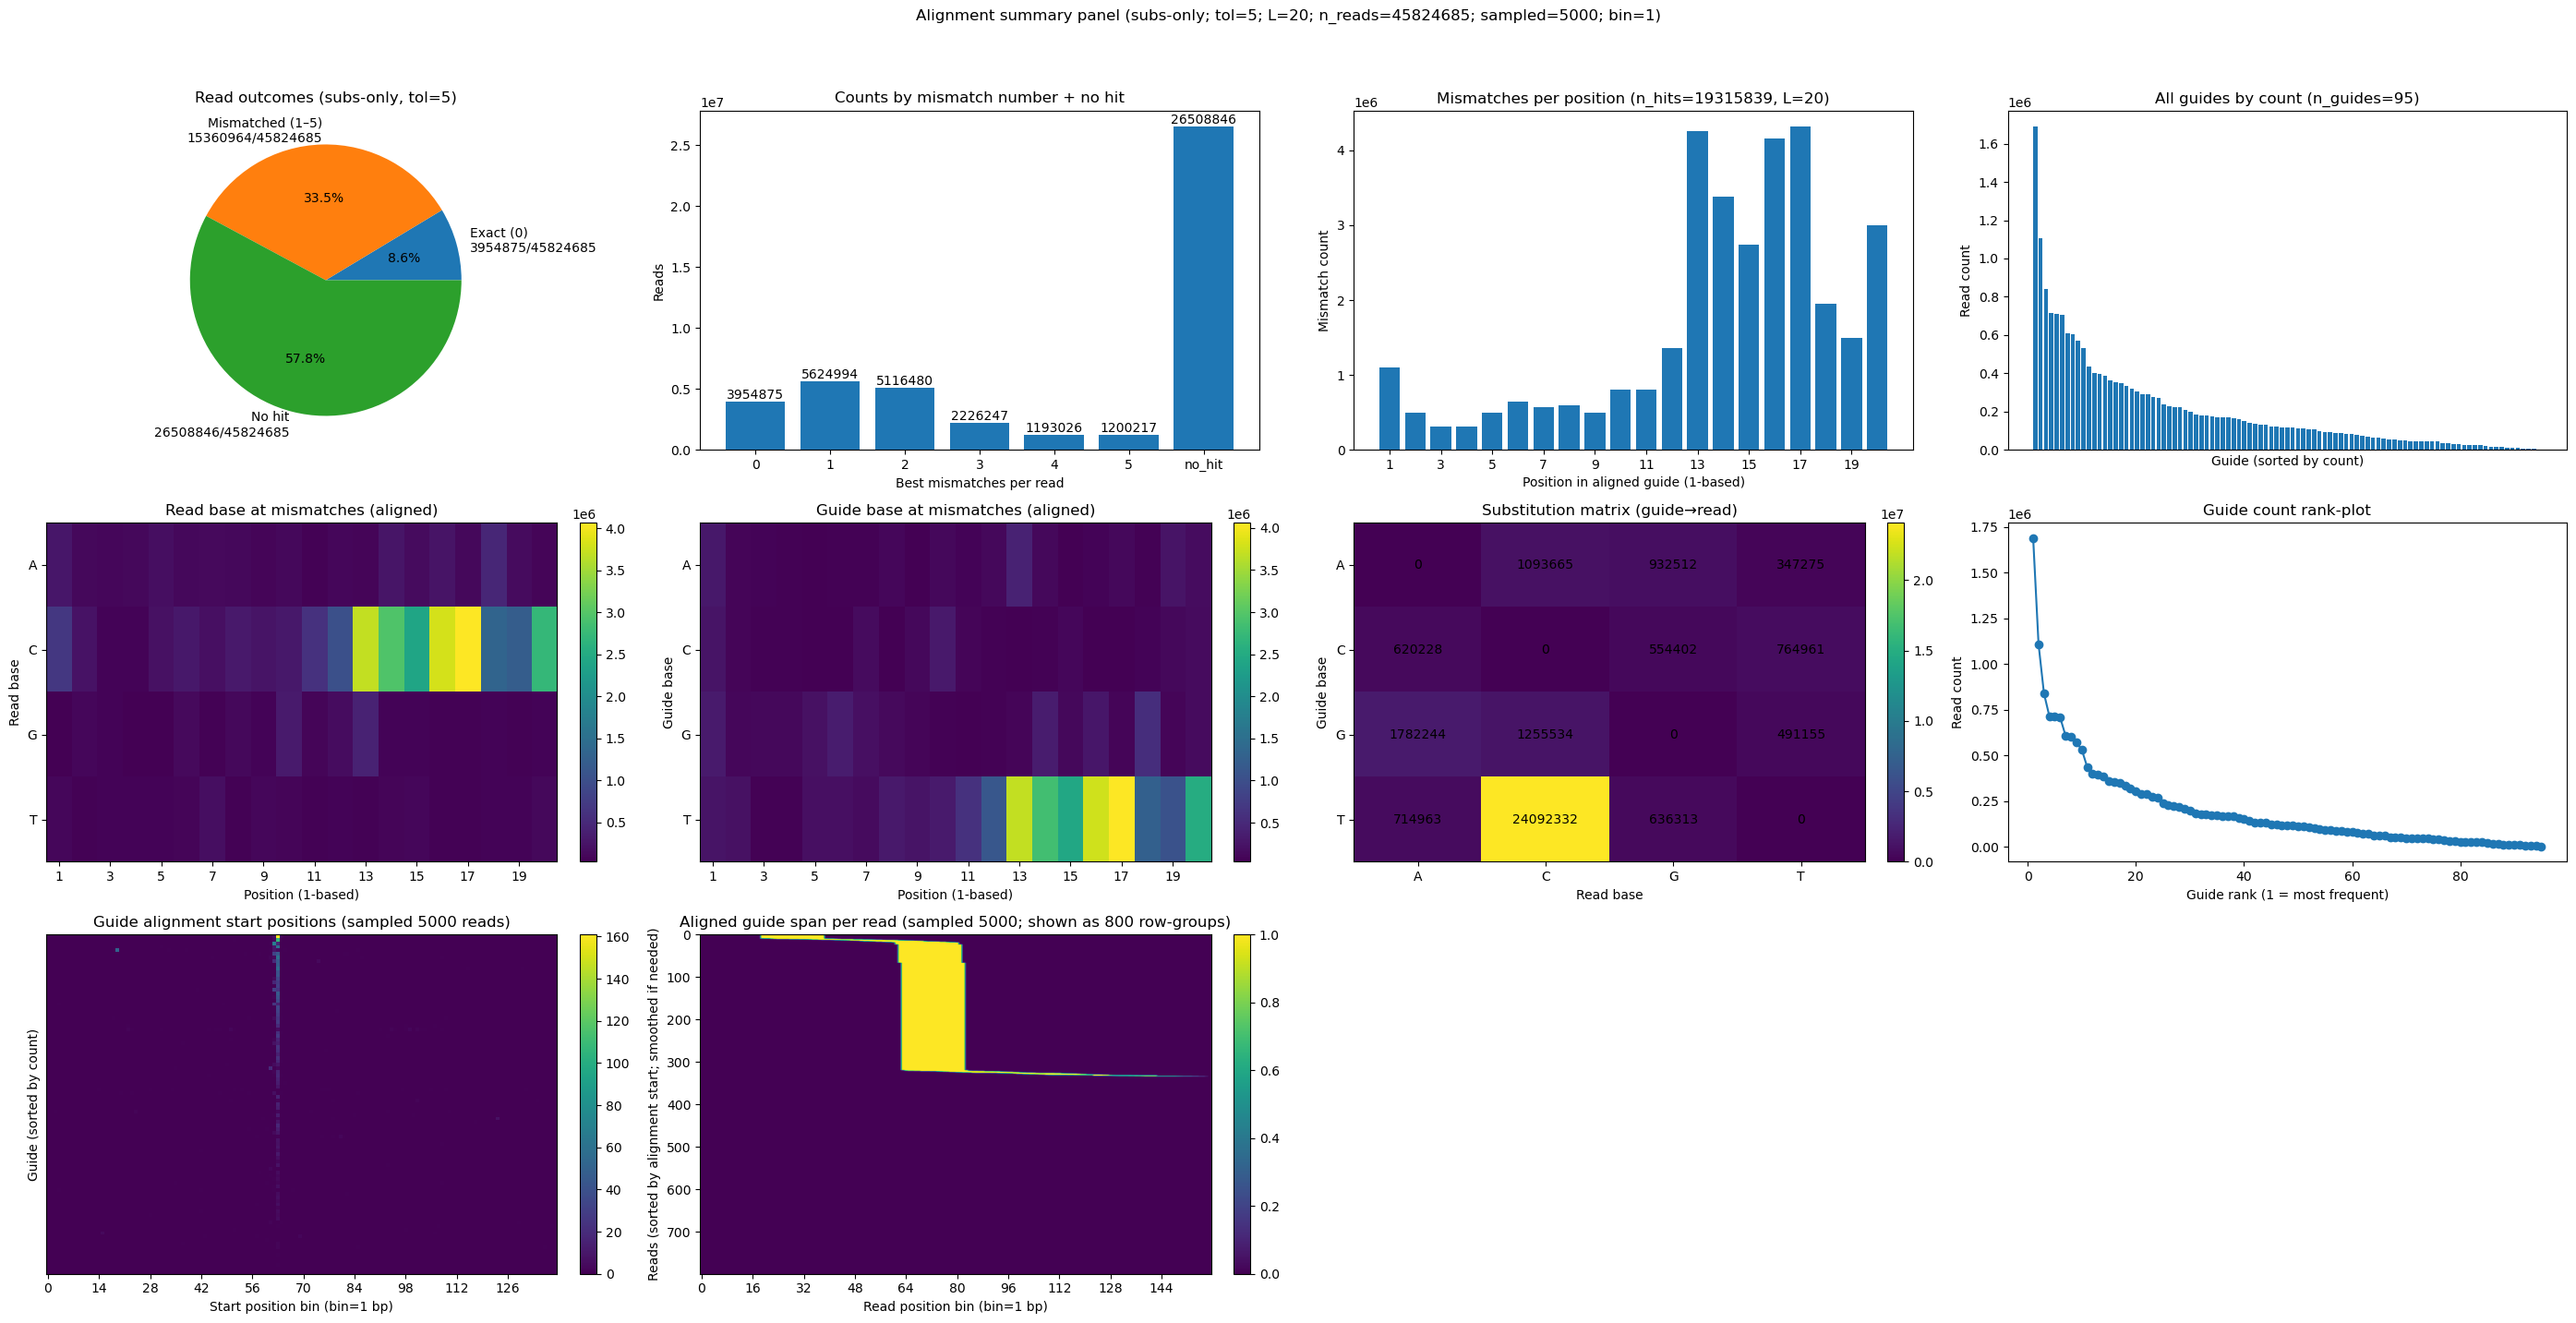


Timing summary:
                             step   seconds           pct
0                   build anndata  3.234765  9.393591e-02
1                           plots  2.402205  6.975879e-02
2               chunk_02201_total  1.918961  5.572564e-02
3               chunk_00862_total  1.672315  4.856316e-02
4               chunk_00374_total  1.521750  4.419085e-02
...                           ...       ...           ...
11460   chunk_00002_umi_aggregate  0.012789  3.713794e-04
11461   chunk_02292_umi_aggregate  0.004979  1.445984e-04
11462  init counters + plot stats  0.000170  4.936493e-06
11463              prepare guides  0.000035  1.024686e-06
11464                  parse tech  0.000007  1.938595e-07

[11465 rows x 3 columns]

Saved AnnData: guide_counts.h5ad
AnnData object with n_obs × n_vars = 527239 × 95
    uns: 'params', 'qc'


In [55]:
#!/usr/bin/env python3
"""
Paired-end FASTQ -> AnnData (cell x guide) with UNIQUE UMI counting + end-of-run plots.

What it does
- Streams R1/R2 FASTQ in chunks (supports .gz)
- Optional kallisto-style barcode/UMI extraction (e.g. "0,0,16:0,16,28")
- Dense GPU Hamming scan (subs-only) to assign best guide anywhere in chosen read (R1 or R2)
- Counts UNIQUE UMIs per (cell barcode, guide) (exact; stores packed 2-bit UMIs in sets)
- Exports AnnData (.h5ad) with:
    obs = cell barcodes
    var = guide sequences
    X   = unique UMI counts (CSR)
- Collects alignment summary stats on-the-fly
- Produces your 3x4 plot panel at the end (using sampled reads for the heatmaps)

Notes on scalability
- Exact unique UMI counting uses Python sets; this is exact but can be memory-heavy at huge scale.
- Plots use reservoir sampling (default 5k reads) so they remain fast and bounded.

Dependencies
- numpy, pandas, matplotlib, torch
- scipy, anndata
"""

import gzip
import time
from dataclasses import dataclass
from typing import Iterator, Tuple, List, Optional, Dict
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import scipy.sparse as sp
import anndata as ad


# ============================================================
# Timing utilities
# ============================================================

class TimerLog:
    def __init__(self):
        self.records = []

    @contextmanager
    def section(self, name: str):
        t0 = time.time()
        yield
        self.records.append((name, time.time() - t0))

    def summary(self, sort=True):
        df = pd.DataFrame(self.records, columns=["step", "seconds"])
        if sort and len(df):
            df = df.sort_values("seconds", ascending=False).reset_index(drop=True)
        total = df["seconds"].sum() if len(df) else 0.0
        df["pct"] = (df["seconds"] / total * 100.0) if total > 0 else 0.0
        return df


# ============================================================
# FASTQ streaming (supports .gz)
# ============================================================

def _open_maybe_gzip(path: str):
    return gzip.open(path, "rt") if path.endswith(".gz") else open(path, "rt")

def fastq_seq_iter(path: str) -> Iterator[str]:
    with _open_maybe_gzip(path) as f:
        while True:
            h = f.readline()
            if not h:
                break
            seq = f.readline().rstrip("\n")
            _ = f.readline()
            _ = f.readline()
            yield seq

def fastq_pair_chunk_iter(r1_path: str, r2_path: str, chunk_size: int) -> Iterator[Tuple[List[str], List[str]]]:
    it1 = fastq_seq_iter(r1_path)
    it2 = fastq_seq_iter(r2_path)
    while True:
        r1, r2 = [], []
        try:
            for _ in range(chunk_size):
                r1.append(next(it1))
                r2.append(next(it2))
        except StopIteration:
            pass
        if not r1:
            break
        m = min(len(r1), len(r2))
        yield r1[:m], r2[:m]
        if m < chunk_size:
            break


# ============================================================
# Kallisto-like technology string parsing
# Example: "0,0,16:0,16,28"
# read index: 0=R1, 1=R2
# ============================================================

def parse_kallisto_tech(tech: str):
    try:
        bc_part, umi_part = tech.split(":")
        br, bs, be = [int(x) for x in bc_part.split(",")]
        ur, us, ue = [int(x) for x in umi_part.split(",")]
        if br not in (0, 1) or ur not in (0, 1):
            raise ValueError("read index must be 0 or 1")
        if not (0 <= bs < be and 0 <= us < ue):
            raise ValueError("invalid slice ranges")
        return (br, bs, be), (ur, us, ue)
    except Exception as e:
        raise ValueError(f"Bad tech string '{tech}'. Expected like '0,0,16:0,16,28'. Error: {e}")

def slice_from_read(seq_r1: str, seq_r2: str, spec: Tuple[int, int, int]) -> str:
    r, s, e = spec
    src = seq_r1 if r == 0 else seq_r2
    return src[s:e]


# ============================================================
# 2-bit packing for memory-efficient UNIQUE UMI counting
# ============================================================

_DNA2BIT = {"A":0,"C":1,"G":2,"T":3,"a":0,"c":1,"g":2,"t":3}

def pack_dna_2bit(seq: str) -> Optional[int]:
    x = 0
    for ch in seq:
        v = _DNA2BIT.get(ch)
        if v is None:
            return None
        x = (x << 2) | v
    return x


# ============================================================
# Dense GPU alignment (subs-only / Hamming)
# ============================================================

_BASE2INT = np.full(256, 4, dtype=np.uint8)
for b, v in [(b"A",0),(b"C",1),(b"G",2),(b"T",3),(b"a",0),(b"c",1),(b"g",2),(b"t",3)]:
    _BASE2INT[b[0]] = v

def encode_seqs_uint8(seqs):
    out = []
    for s in seqs:
        bs = str(s).encode("ascii", "ignore")
        arr = np.frombuffer(bs, dtype=np.uint8)
        out.append(_BASE2INT[arr])
    return out

def pad_reads_u8(encoded_list, pad_value=4):
    lengths = np.array([len(x) for x in encoded_list], dtype=np.int32)
    max_len = int(lengths.max()) if len(lengths) else 0
    mat = np.full((len(encoded_list), max_len), pad_value, dtype=np.uint8)
    for i, x in enumerate(encoded_list):
        mat[i, :len(x)] = x
    return mat, lengths, max_len

def _gpu_mem_str(device="cuda"):
    if not (torch.cuda.is_available() and str(device).startswith("cuda")):
        return ""
    dev = torch.device(device)
    alloc = torch.cuda.memory_allocated(dev) / (1024**3)
    reserv = torch.cuda.memory_reserved(dev) / (1024**3)
    max_alloc = torch.cuda.max_memory_allocated(dev) / (1024**3)
    free, total = torch.cuda.mem_get_info(dev)
    used = (total - free) / (1024**3)
    total_gb = total / (1024**3)
    return (f" | GPU mem GB: alloc={alloc:.2f} reserved={reserv:.2f} "
            f"max_alloc={max_alloc:.2f} driver_used={used:.2f}/{total_gb:.2f}")

@torch.no_grad()
def gpu_best_hits_dense(
    reads_str: List[str],
    guides_str: List[str],
    L: int,
    tolerance: int,
    device: str = "cuda",
    read_chunk: int = 4096,
):
    """
    Dense scan for a list of reads.
    Returns best_dist (int32), best_start (int32), best_gid (int32).
    """
    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but not available.")
    dev = torch.device(device)

    # guides -> [G,L]
    enc_guides = encode_seqs_uint8(guides_str)
    guide_mat = np.stack([g[:L] for g in enc_guides], axis=0).astype(np.uint8)
    guide_t = torch.from_numpy(guide_mat).to(device=dev, dtype=torch.uint8)
    G = guide_t.shape[0]

    out_dist, out_start, out_gid = [], [], []
    n_reads = len(reads_str)

    for i0 in range(0, n_reads, read_chunk):
        chunk = reads_str[i0:i0+read_chunk]
        enc_reads = encode_seqs_uint8(chunk)
        read_mat, lengths, Rmax = pad_reads_u8(enc_reads, pad_value=4)
        B = read_mat.shape[0]

        if Rmax < L:
            out_dist.append(np.full((B,), 10**9, dtype=np.int32))
            out_start.append(np.full((B,), -1, dtype=np.int32))
            out_gid.append(np.full((B,), -1, dtype=np.int32))
            continue

        read_t = torch.from_numpy(read_mat).to(device=dev, dtype=torch.uint8)     # [B,Rmax]
        lens_t = torch.from_numpy(lengths).to(device=dev, dtype=torch.int32)      # [B]
        Smax = Rmax - L + 1

        win = read_t.unfold(1, L, 1)  # [B,S,L]

        max_start_each = (lens_t - L).clamp(min=-1)
        starts = torch.arange(0, Smax, device=dev, dtype=torch.int32)[None, :]
        valid = starts <= max_start_each[:, None]

        mism = torch.sum(win[:, :, None, :] != guide_t[None, None, :, :], dim=-1, dtype=torch.int16)
        mism = torch.where(valid[:, :, None], mism, torch.tensor(32767, device=dev, dtype=torch.int16))

        flat = mism.reshape(B, Smax * G)
        best_dist_i16, argmin = torch.min(flat, dim=1)

        best_start_i32 = (argmin // G).to(torch.int32)
        best_gid_i32 = (argmin % G).to(torch.int32)

        ok = best_dist_i16 <= tolerance
        best_dist_i32 = best_dist_i16.to(torch.int32)
        best_dist_i32 = torch.where(ok, best_dist_i32, torch.tensor(10**9, device=dev, dtype=torch.int32))
        best_start_i32 = torch.where(ok, best_start_i32, torch.tensor(-1, device=dev, dtype=torch.int32))
        best_gid_i32 = torch.where(ok, best_gid_i32, torch.tensor(-1, device=dev, dtype=torch.int32))

        out_dist.append(best_dist_i32.cpu().numpy())
        out_start.append(best_start_i32.cpu().numpy())
        out_gid.append(best_gid_i32.cpu().numpy())

    return np.concatenate(out_dist), np.concatenate(out_start), np.concatenate(out_gid)


# ============================================================
# Counting unique UMIs per (barcode, guide)
# cell_key(int)-> guide_id(int) -> set(umi_key(int))
# ============================================================

def add_umi(cell_map: Dict[int, Dict[int, set]], cell_key: int, gid: int, umi_key: int):
    gmap = cell_map.get(cell_key)
    if gmap is None:
        gmap = {}
        cell_map[cell_key] = gmap
    s = gmap.get(gid)
    if s is None:
        s = set()
        gmap[gid] = s
    s.add(umi_key)


# ============================================================
# Plot stats accumulator (streaming)
# ============================================================

@dataclass
class PlotStats:
    tol: int
    L: int
    n_guides: int
    pos_bin_size: int = 1
    sample_n: int = 5000
    sample_seed: int = 0

    # global counts
    total_reads: int = 0
    no_hit: int = 0
    dist_counts: Optional[np.ndarray] = None  # (tol+1,)
    mismatch_pos_counts: Optional[np.ndarray] = None  # (L,)
    read_base_at_mismatch: Optional[np.ndarray] = None  # (4,L)
    proto_base_at_mismatch: Optional[np.ndarray] = None  # (4,L)
    sub_matrix: Optional[np.ndarray] = None  # (4,4)
    guide_counts: Optional[np.ndarray] = None  # (G,)

    # reservoir sample storage for heatmaps
    rng: Optional[np.random.Generator] = None
    sample_filled: int = 0
    sample_seen: int = 0
    sample_read_len: Optional[np.ndarray] = None  # (K,)
    sample_start: Optional[np.ndarray] = None     # (K,)
    sample_end: Optional[np.ndarray] = None       # (K,)
    sample_gid: Optional[np.ndarray] = None       # (K,)

    max_read_len_seen: int = 0

    def __post_init__(self):
        self.dist_counts = np.zeros(self.tol + 1, dtype=np.int64)
        self.mismatch_pos_counts = np.zeros(self.L, dtype=np.int64)
        self.read_base_at_mismatch = np.zeros((4, self.L), dtype=np.int64)
        self.proto_base_at_mismatch = np.zeros((4, self.L), dtype=np.int64)
        self.sub_matrix = np.zeros((4, 4), dtype=np.int64)
        self.guide_counts = np.zeros(self.n_guides, dtype=np.int64)

        self.rng = np.random.default_rng(self.sample_seed)
        K = self.sample_n
        self.sample_read_len = np.zeros(K, dtype=np.int32)
        self.sample_start = np.full(K, -1, dtype=np.int32)
        self.sample_end = np.full(K, -1, dtype=np.int32)
        self.sample_gid = np.full(K, -1, dtype=np.int32)

    @staticmethod
    def _b2i(ch: str) -> int:
        # A,C,G,T -> 0..3 else -1
        if ch == "A": return 0
        if ch == "C": return 1
        if ch == "G": return 2
        if ch == "T": return 3
        return -1

    def _maybe_reservoir_store(self, read_len: int, start: int, end: int, gid: int):
        """
        Reservoir sampling over all reads.
        """
        self.sample_seen += 1
        if self.sample_filled < self.sample_n:
            j = self.sample_filled
            self.sample_filled += 1
        else:
            # replace with prob K/seen
            r = self.rng.integers(0, self.sample_seen)
            if r >= self.sample_n:
                return
            j = int(r)

        self.sample_read_len[j] = read_len
        self.sample_start[j] = start
        self.sample_end[j] = end
        self.sample_gid[j] = gid

    def update_from_chunk(
        self,
        reads: List[str],
        guides: List[str],
        best_dist: np.ndarray,
        best_start: np.ndarray,
        best_gid: np.ndarray,
    ):
        """
        Update global stats and reservoir sample from one chunk.
        """
        self.total_reads += len(reads)
        self.max_read_len_seen = max(self.max_read_len_seen, max((len(r) for r in reads), default=0))

        for r, d, s, gid in zip(reads, best_dist, best_start, best_gid):
            if gid < 0 or s < 0 or d >= 10**8:
                self.no_hit += 1
                self._maybe_reservoir_store(len(r), -1, -1, -1)
                continue

            d = int(d); s = int(s); gid = int(gid)
            e = s + self.L

            # counts
            if d <= self.tol:
                self.dist_counts[d] += 1
            else:
                # should not happen (gated), treat as no-hit
                self.no_hit += 1
                self._maybe_reservoir_store(len(r), -1, -1, -1)
                continue

            self.guide_counts[gid] += 1

            # mismatch bookkeeping (uses strings; L=20 so cheap)
            proto = guides[gid]
            window = r[s:e]
            for j, (rb, pb) in enumerate(zip(window, proto)):
                if rb != pb:
                    self.mismatch_pos_counts[j] += 1
                    ri = self._b2i(rb)
                    pi = self._b2i(pb)
                    if ri >= 0:
                        self.read_base_at_mismatch[ri, j] += 1
                    if pi >= 0:
                        self.proto_base_at_mismatch[pi, j] += 1
                    if (ri >= 0) and (pi >= 0):
                        self.sub_matrix[pi, ri] += 1

            # sample
            self._maybe_reservoir_store(len(r), s, e, gid)


# ============================================================
# Plot rendering (your 3x4 panel)
# Uses:
# - global stats for most panels
# - sampled reads for guide-start heatmap and read-span heatmap
# ============================================================

def downsample_rows_mean(mat: np.ndarray, target_rows: int):
    n_rows = mat.shape[0]
    if n_rows <= target_rows or target_rows <= 0:
        return mat, np.ones(n_rows, dtype=int)

    edges = np.linspace(0, n_rows, target_rows + 1).astype(int)
    out = np.zeros((target_rows, mat.shape[1]), dtype=float)
    sizes = np.zeros(target_rows, dtype=int)

    for i in range(target_rows):
        a, b = edges[i], edges[i + 1]
        if b <= a:
            b = min(n_rows, a + 1)
        block = mat[a:b]
        out[i] = block.mean(axis=0)
        sizes[i] = b - a

    return out, sizes


def plot_alignment_panel_from_stats(
    stats: PlotStats,
    guides: List[str],
    pos_bin_size: int = 1,
    read_heatmap_max_rows: int = 800,
):
    tol = stats.tol
    L = stats.L
    total = stats.total_reads
    no_hit = stats.no_hit
    exact = int(stats.dist_counts[0]) if tol >= 0 else 0
    mismatched_any = total - exact - no_hit
    used_hits = total - no_hit

    # guides counts series
    guide_counts_s = pd.Series(stats.guide_counts, index=np.arange(stats.n_guides)).sort_values(ascending=False)

    # sampled set
    K = stats.sample_filled
    s_start = stats.sample_start[:K]
    s_end = stats.sample_end[:K]
    s_gid = stats.sample_gid[:K]
    s_rlen = stats.sample_read_len[:K]

    # bins for guide-start heatmap
    max_read_len = max(1, stats.max_read_len_seen)
    max_start = max(0, max_read_len - L)
    n_bins = (max_start // pos_bin_size) + 1

    # guide-start heatmap (SAMPLED, vectorized)
    align_heat_guides = np.zeros((stats.n_guides, n_bins), dtype=np.int32)
    ok = (s_gid >= 0) & (s_start >= 0)
    if np.any(ok):
        g_rows = s_gid[ok].astype(np.int32, copy=False)
        s_bins = (s_start[ok] // pos_bin_size).astype(np.int32, copy=False)
        s_bins = np.clip(s_bins, 0, n_bins - 1)
        np.add.at(align_heat_guides, (g_rows, s_bins), 1)

    # read-span heatmap (SAMPLED): rows=reads sorted by start
    # x bins from max_read_len_seen
    n_pos_bins = (max_read_len // pos_bin_size) + 1
    order = np.argsort(np.where(ok, s_start, 10**12)[:K])
    read_span_heat = np.zeros((K, n_pos_bins), dtype=float)
    for row_i, j in enumerate(order):
        if s_start[j] < 0 or s_end[j] < 0:
            continue
        b0 = max(0, int(s_start[j] // pos_bin_size))
        b1 = min(n_pos_bins, int((s_end[j] - 1) // pos_bin_size + 1))
        if b1 > b0:
            read_span_heat[row_i, b0:b1] = 1.0

    read_span_heat_plot, _ = downsample_rows_mean(read_span_heat, read_heatmap_max_rows)

    # figure
    fig, axes = plt.subplots(3, 4, figsize=(28, 14))

    # (1) PIE outcomes
    ax = axes[0, 0]
    pie_sizes = [exact, mismatched_any, no_hit]
    pie_labels = [
        f"Exact (0)\n{exact}/{total}",
        f"Mismatched (1–{tol})\n{mismatched_any}/{total}",
        f"No hit\n{no_hit}/{total}",
    ]
    ax.pie(pie_sizes, labels=pie_labels, autopct=lambda p: f"{p:.1f}%")
    ax.set_title(f"Read outcomes (subs-only, tol={tol})")

    # (2) BAR mismatch distribution
    ax = axes[0, 1]
    x_labels = [str(k) for k in range(tol + 1)] + ["no_hit"]
    y = [int(stats.dist_counts[k]) for k in range(tol + 1)] + [int(no_hit)]
    x = np.arange(len(x_labels))
    ax.bar(x, y)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel("Best mismatches per read")
    ax.set_ylabel("Reads")
    ax.set_title("Counts by mismatch number + no hit")
    for xi, yi in zip(x, y):
        ax.text(xi, yi, str(yi), ha="center", va="bottom")

    # (3) BAR mismatch-by-position (aligned to guide)
    ax = axes[0, 2]
    pos_x = np.arange(1, L + 1)
    ax.bar(pos_x, stats.mismatch_pos_counts)
    ax.set_xlabel("Position in aligned guide (1-based)")
    ax.set_ylabel("Mismatch count")
    ax.set_title(f"Mismatches per position (n_hits={used_hits}, L={L})")
    step = max(1, L // 10)
    xt = np.arange(1, L + 1, step)
    ax.set_xticks(xt)
    ax.set_xticklabels([str(v) for v in xt])

    # (4) ALL-guides bar plot (sorted)
    ax = axes[0, 3]
    if guide_counts_s.sum() == 0:
        ax.text(0.5, 0.5, "No guide hits", ha="center", va="center")
        ax.set_axis_off()
    else:
        ax.bar(np.arange(len(guide_counts_s)), guide_counts_s.values)
        ax.set_xlabel("Guide (sorted by count)")
        ax.set_ylabel("Read count")
        ax.set_title(f"All guides by count (n_guides={len(guide_counts_s)})")
        ax.set_xticks([])

    bases = ["A", "C", "G", "T"]

    # (5) Heatmap read base at mismatches
    ax = axes[1, 0]
    im = ax.imshow(stats.read_base_at_mismatch, aspect="auto")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(bases)
    ax.set_xticks(np.arange(0, L, step))
    ax.set_xticklabels([str(v) for v in range(1, L + 1, step)])
    ax.set_xlabel("Position (1-based)")
    ax.set_ylabel("Read base")
    ax.set_title("Read base at mismatches (aligned)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (6) Heatmap guide base at mismatches
    ax = axes[1, 1]
    im = ax.imshow(stats.proto_base_at_mismatch, aspect="auto")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(bases)
    ax.set_xticks(np.arange(0, L, step))
    ax.set_xticklabels([str(v) for v in range(1, L + 1, step)])
    ax.set_xlabel("Position (1-based)")
    ax.set_ylabel("Guide base")
    ax.set_title("Guide base at mismatches (aligned)")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (7) Substitution matrix
    ax = axes[1, 2]
    im = ax.imshow(stats.sub_matrix, aspect="auto")
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(bases)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(bases)
    ax.set_xlabel("Read base")
    ax.set_ylabel("Guide base")
    ax.set_title("Substitution matrix (guide→read)")
    for i in range(4):
        for j in range(4):
            ax.text(j, i, str(int(stats.sub_matrix[i, j])), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (8) Guide rank plot
    ax = axes[1, 3]
    if guide_counts_s.sum() == 0:
        ax.text(0.5, 0.5, "No guide hits", ha="center", va="center")
        ax.set_axis_off()
    else:
        ranks = np.arange(1, len(guide_counts_s) + 1)
        ax.plot(ranks, guide_counts_s.values, marker="o", linestyle="-")
        ax.set_xlabel("Guide rank (1 = most frequent)")
        ax.set_ylabel("Read count")
        ax.set_title("Guide count rank-plot")

    # (9) Heatmap: guides x read-start bins (sampled)
    ax = axes[2, 0]
    if align_heat_guides.sum() == 0:
        ax.text(0.5, 0.5, "No alignments to plot", ha="center", va="center")
        ax.set_axis_off()
    else:
        # reorder rows by overall guide frequency (descending) for nicer view
        guide_order = guide_counts_s.index.to_numpy(dtype=int)
        im = ax.imshow(align_heat_guides[guide_order, :], aspect="auto")
        ax.set_ylabel("Guide (sorted by count)")
        ax.set_xlabel(f"Start position bin (bin={pos_bin_size} bp)")
        ax.set_title(f"Guide alignment start positions (sampled {K} reads)")
        ax.set_yticks([])
        tick_step = max(1, n_bins // 10)
        xticks = np.arange(0, n_bins, tick_step)
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(int(t * pos_bin_size)) for t in xticks])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # (10) Heatmap: reads x read-position span (sampled)
    ax = axes[2, 1]
    if np.nansum(read_span_heat_plot) == 0:
        ax.text(0.5, 0.5, "No read spans to plot", ha="center", va="center")
        ax.set_axis_off()
    else:
        im = ax.imshow(read_span_heat_plot, aspect="auto")
        ax.set_xlabel(f"Read position bin (bin={pos_bin_size} bp)")
        ax.set_ylabel("Reads (sorted by alignment start; smoothed if needed)")
        ax.set_title(f"Aligned guide span per read (sampled {K}; shown as {read_span_heat_plot.shape[0]} row-groups)")
        tick_step = max(1, read_span_heat_plot.shape[1] // 10)
        xticks = np.arange(0, read_span_heat_plot.shape[1], tick_step)
        ax.set_xticks(xticks)
        ax.set_xticklabels([str(int(t * pos_bin_size)) for t in xticks])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    axes[2, 2].set_axis_off()
    axes[2, 3].set_axis_off()

    fig.suptitle(
        f"Alignment summary panel (subs-only; tol={tol}; L={L}; n_reads={total}; sampled={K}; bin={pos_bin_size})",
        y=1.02
    )
    fig.tight_layout()
    plt.show()


# ============================================================
# Main pipeline: paired FASTQ -> AnnData + plots
# ============================================================

def process_paired_fastq_to_anndata_with_plots(
    r1_path: str,
    r2_path: str,
    protospacers_match: List[str],
    out_h5ad: str,
    # guide alignment
    guide_len: int = 20,
    tolerance: int = 5,
    align_on_read: int = 1,          # 0=R1, 1=R2 (default align on R2)
    gpu_read_chunk: int = 4096,
    device: str = "cuda",
    # chunking
    fastq_chunk_size: int = 200000,  # FASTQ records per chunk
    # barcode/UMI extraction
    tech: Optional[str] = "0,0,16:0,16,28",
    extract_bc_umi: bool = True,
    # plotting sample
    plot_sample_n: int = 5000,
    plot_sample_seed: int = 0,
    plot_pos_bin_size: int = 1,
    plot_read_heatmap_max_rows: int = 800,
    # progress
    progress_every_chunks: int = 1,
):
    T = TimerLog()

    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but torch.cuda.is_available() is False.")

    with T.section("prepare guides"):
        guides = [str(g)[:guide_len] for g in protospacers_match]
        seen = set()
        guides = [g for g in guides if len(g) == guide_len and not (g in seen or seen.add(g))]
        G = len(guides)
        if G == 0:
            raise ValueError("No valid guides after clipping/dedup.")

    with T.section("parse tech"):
        if extract_bc_umi:
            if tech is None:
                raise ValueError("extract_bc_umi=True requires a tech spec string.")
            bc_spec, umi_spec = parse_kallisto_tech(tech)
        else:
            bc_spec = umi_spec = None

    with T.section("init counters + plot stats"):
        barcode_key_to_str: Dict[int, str] = {}
        cell_guide_umis: Dict[int, Dict[int, set]] = {}
        stats = PlotStats(
            tol=tolerance,
            L=guide_len,
            n_guides=G,
            pos_bin_size=plot_pos_bin_size,
            sample_n=plot_sample_n,
            sample_seed=plot_sample_seed,
        )

        n_pairs = 0
        n_assigned = 0
        n_nohit = 0
        n_bad_bc = 0
        n_bad_umi = 0

    t0 = time.time()

    for chunk_i, (r1_seqs, r2_seqs) in enumerate(fastq_pair_chunk_iter(r1_path, r2_path, fastq_chunk_size), start=1):
        with T.section(f"chunk_{chunk_i:05d}_total"):
            n = len(r1_seqs)
            n_pairs += n

            # Extract barcodes/UMIs (CPU)
            with T.section(f"chunk_{chunk_i:05d}_bc_umi"):
                if extract_bc_umi:
                    bc_keys = np.empty(n, dtype=np.int64)
                    umi_keys = np.empty(n, dtype=np.int64)
                    valid_bu = np.ones(n, dtype=bool)

                    for i, (s1, s2) in enumerate(zip(r1_seqs, r2_seqs)):
                        bc = slice_from_read(s1, s2, bc_spec)
                        umi = slice_from_read(s1, s2, umi_spec)

                        bc_k = pack_dna_2bit(bc)
                        umi_k = pack_dna_2bit(umi)

                        if bc_k is None:
                            valid_bu[i] = False
                            n_bad_bc += 1
                            continue
                        if umi_k is None:
                            valid_bu[i] = False
                            n_bad_umi += 1
                            continue

                        bc_keys[i] = bc_k
                        umi_keys[i] = umi_k
                        if bc_k not in barcode_key_to_str:
                            barcode_key_to_str[bc_k] = bc
                else:
                    bc_keys = np.zeros(n, dtype=np.int64)
                    umi_keys = np.arange(n, dtype=np.int64)
                    valid_bu = np.ones(n, dtype=bool)
                    if 0 not in barcode_key_to_str:
                        barcode_key_to_str[0] = "CELL"

            # Choose read for alignment
            align_reads = r2_seqs if align_on_read == 1 else r1_seqs

            # Align on GPU
            with T.section(f"chunk_{chunk_i:05d}_gpu_align"):
                best_dist, best_start, best_gid = gpu_best_hits_dense(
                    align_reads, guides, L=guide_len, tolerance=tolerance, device=device, read_chunk=gpu_read_chunk
                )

            # Update plot stats (global counts + reservoir sample)
            with T.section(f"chunk_{chunk_i:05d}_plot_stats_update"):
                stats.update_from_chunk(align_reads, guides, best_dist, best_start, best_gid)

            # Aggregate unique UMIs
            with T.section(f"chunk_{chunk_i:05d}_umi_aggregate"):
                for i in range(n):
                    if not valid_bu[i]:
                        continue
                    gid = int(best_gid[i])
                    if gid < 0:
                        n_nohit += 1
                        continue
                    n_assigned += 1
                    add_umi(cell_guide_umis, int(bc_keys[i]), gid, int(umi_keys[i]))

        if (chunk_i % max(1, progress_every_chunks) == 0):
            elapsed = time.time() - t0
            rate = n_pairs / max(elapsed, 1e-9)
            print(
                f"[chunk {chunk_i}] pairs={n_pairs:,} assigned={n_assigned:,} no_hit={n_nohit:,} "
                f"bad_bc={n_bad_bc:,} bad_umi={n_bad_umi:,} | {rate:,.0f} pairs/s{_gpu_mem_str(device)}"
            )

    # Build AnnData
    with T.section("build anndata"):
        cell_keys = np.array(sorted(cell_guide_umis.keys()), dtype=np.int64)
        n_cells = len(cell_keys)
        cell_row = {ck: i for i, ck in enumerate(cell_keys)}

        rows, cols, vals = [], [], []
        for ck, gmap in cell_guide_umis.items():
            r = cell_row[ck]
            for gid, umiset in gmap.items():
                rows.append(r)
                cols.append(gid)
                vals.append(len(umiset))

        X = sp.csr_matrix((vals, (rows, cols)), shape=(n_cells, G), dtype=np.int32)

        obs_names = [barcode_key_to_str[int(ck)] for ck in cell_keys]
        var_names = guides

        adata = ad.AnnData(X=X)
        adata.obs_names = obs_names
        adata.var_names = var_names
        adata.uns["params"] = dict(
            r1_path=r1_path,
            r2_path=r2_path,
            guide_len=guide_len,
            tolerance=tolerance,
            align_on_read=align_on_read,
            tech=tech,
            extract_bc_umi=extract_bc_umi,
            fastq_chunk_size=fastq_chunk_size,
            gpu_read_chunk=gpu_read_chunk,
            device=device,
            plot_sample_n=plot_sample_n,
            plot_sample_seed=plot_sample_seed,
        )
        adata.uns["qc"] = dict(
            total_pairs=int(n_pairs),
            assigned=int(n_assigned),
            no_hit=int(n_nohit),
            bad_bc=int(n_bad_bc),
            bad_umi=int(n_bad_umi),
            n_cells=int(n_cells),
            n_guides=int(G),
        )

        adata.write_h5ad(out_h5ad)

    # Plots (your panel)
    with T.section("plots"):
        plot_alignment_panel_from_stats(
            stats=stats,
            guides=guides,
            pos_bin_size=plot_pos_bin_size,
            read_heatmap_max_rows=plot_read_heatmap_max_rows,
        )

    timings_df = T.summary(sort=True)
    print("\nTiming summary:")
    print(timings_df)

    print(f"\nSaved AnnData: {out_h5ad}")
    print(adata)
    return adata, stats, timings_df





# ============================================================
#Example usage
##============================================================
adata, stats, timings_df  = process_paired_fastq_to_anndata_with_plots(
    r1_path="/PHShome/lf588/scratch/quang_dataset/data/cloud/sample_Jing/combined_CRISPR_S1_L001_R1_001.fastq.gz",
    r2_path="/PHShome/lf588/scratch/quang_dataset/data/cloud/sample_Jing/combined_CRISPR_S1_L001_R2_001.fastq.gz",
    protospacers_match=quang_guides,  # list of guide sequences (strings)
    out_h5ad="guide_counts.h5ad",
    guide_len=20,
    tolerance=5,
    align_on_read=1,               # align on R2
    gpu_read_chunk=2000,
    device=1,
    fastq_chunk_size=20000,
    tech="0,0,16:0,16,28",         # barcode+umi from R1 like kallisto
    extract_bc_umi=True,
    progress_every_chunks=10,
    plot_sample_n=5000,            # used for both heatmaps
    plot_sample_seed=0,
    plot_pos_bin_size=1,
    plot_read_heatmap_max_rows=800,
)




In [43]:
(adata.X.sum(1) > 30).sum()

7651

In [ ]:


import torch
# Now PyTorch thinks there are only 2 GPUs. 
# System GPU 1 is now "cuda:0" and System GPU 2 is "cuda:1"
print(torch.cuda.device_count()) # Output: 2

torch.cuda.device(1)  # This will refer to the original GPU 1

2


In [27]:
torch.cuda.get_device_name(torch.cuda.device(1))

'NVIDIA A100-PCIE-40GB'

In [28]:
import torch

# Define the second GPU as the target
device_id = "cuda:1"

# Check availability specifically for that device
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    dev = torch.device(device_id)
else:
    # Fallback logic if the second GPU isn't available
    device_id = "cpu"
    dev = torch.device("cpu")
    print("Second GPU not found, falling back to CPU.")

print(f"Using: {torch.cuda.get_device_name(dev)}")

Using: NVIDIA A100-PCIE-40GB
